In [1]:
from pystac_client import Client
import planetary_computer

# Connect to the Planetary Computer STAC API
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

print("Connected to:", catalog.title)


Connected to: Microsoft Planetary Computer STAC API


In [6]:
import geopandas as gpd

gdb_path = r"data\hydrolakes\HydroLAKES_polys_v10.gdb" 
gdf = gpd.read_file(gdb_path, engine="pyogrio")

# Print all the column names so we can find the right ones
print(gdf.columns.tolist())


['Hylak_id', 'Lake_name', 'Country', 'Continent', 'Poly_src', 'Lake_type', 'Grand_id', 'Lake_area', 'Shore_len', 'Shore_dev', 'Vol_total', 'Vol_res', 'Vol_src', 'Depth_avg', 'Dis_avg', 'Res_time', 'Elevation', 'Slope_100', 'Wshd_area', 'Pour_long', 'Pour_lat', 'Shape_Length', 'Shape_Area', 'geometry']


In [ ]:
import os
import geopandas as gpd

gdb_path = r"data\hydrolakes\HydroLAKES_polys_v10.gdb" 
print("Loading and filtering HydroLAKES...")
gdf = gpd.read_file(gdb_path, engine="pyogrio")

# 1. Filter for human-managed reservoirs (Type 2) and area >= 1.0 km²
reservoirs = gdf[(gdf['Lake_type'] == 2) & (gdf['Lake_area'] >= 1.0)]

# 2. Search for Orlík
orlik = reservoirs[reservoirs['Lake_name'].str.contains('Orlik', case=False, na=False)]

print("\nFound Reservoir:")
display(orlik[['Hylak_id', 'Lake_name', 'Country', 'Lake_area']])

# 3. Extract the bounding box [min_lon, min_lat, max_lon, max_lat]
orlik_bbox = list(orlik.total_bounds)
print(f"\nOrlík Bounding Box: {orlik_bbox}")

# 4. Save to GeoJSON so we don't have to load the huge GDB again
output_dir = r"data\hydrolakes"
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, "orlik_reservoir.geojson")
orlik.to_file(output_file, driver="GeoJSON")
print(f"Saved Orlík geometry to: {output_file}")


Loading and filtering HydroLAKES...

Found Reservoir:


,Hylak_id,Lake_name,Country,Lake_area



Orlík Bounding Box: [np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]
Saved Orlík geometry to: data\hydrolakes\orlik_reservoir.geojson


In [8]:
# Search for lakes in Czechia/Czech Republic
cz_lakes = reservoirs[reservoirs['Country'].str.contains('Czech', case=False, na=False)]

# Sort them by area so the biggest ones are at the top
cz_top_lakes = cz_lakes[['Hylak_id', 'Lake_name', 'Lake_area']].sort_values('Lake_area', ascending=False)

# Show the top 10
display(cz_top_lakes.head(10))


,Hylak_id,Lake_name,Lake_area
13920,13921,,43.779999
13890,13891,,22.750000
13817,13818,,15.070000
13810,13811,,11.460000
13762,13763,,11.230000
13798,13799,,10.360000
166716,166717,,8.270000
167102,167103,,7.110000
166934,166935,,6.010000
167946,167947,,5.150000


In [9]:
import os

# Grab Orlík using its exact Hylak_id
orlik = reservoirs[reservoirs['Hylak_id'] == 13891]

# Extract the bounding box [min_lon, min_lat, max_lon, max_lat]
orlik_bbox = list(orlik.total_bounds)
print(f"\nOrlík Bounding Box: {orlik_bbox}")

# Overwrite the empty GeoJSON with the real data
output_dir = r"data\hydrolakes"
output_file = os.path.join(output_dir, "orlik_reservoir.geojson")
orlik.to_file(output_file, driver="GeoJSON")

print(f"Successfully saved Orlík geometry to: {output_file}")



Orlík Bounding Box: [np.float64(16.58555243598147), np.float64(48.855972222222476), np.float64(16.72721950954923), np.float64(48.91444166395428)]
Successfully saved Orlík geometry to: data\hydrolakes\orlik_reservoir.geojson


In [10]:
import os

# Grab Nové Mlýny using its exact Hylak_id (13891)
nove_mlyny = reservoirs[reservoirs['Hylak_id'] == 13891].copy()

# Let's fix the missing name in the data while we are at it
nove_mlyny['Lake_name'] = 'Nové Mlýny'

# Extract the bounding box [min_lon, min_lat, max_lon, max_lat]
nm_bbox = list(nove_mlyny.total_bounds)
print(f"\nNové Mlýny Bounding Box: {nm_bbox}")

# Save with the correct filename
output_dir = r"data\hydrolakes"
output_file = os.path.join(output_dir, "nove_mlyny.geojson")
nove_mlyny.to_file(output_file, driver="GeoJSON")

print(f"Successfully saved Nové Mlýny geometry to: {output_file}")



Nové Mlýny Bounding Box: [np.float64(16.58555243598147), np.float64(48.855972222222476), np.float64(16.72721950954923), np.float64(48.91444166395428)]
Successfully saved Nové Mlýny geometry to: data\hydrolakes\nove_mlyny.geojson


In [11]:
print(f"Searching for images in bbox: {nm_bbox}")

# Search the Planetary Computer STAC API
search = catalog.search(
    collections=["sentinel-2-l2a"], 
    bbox=nm_bbox,
    datetime="2023-07-01/2023-08-31", # Summer 2023
    query={"eo:cloud_cover": {"lt": 10}} # Less than 10% cloud cover
)

# Fetch the results
items = search.item_collection()
print(f"Found {len(items)} Sentinel-2 scenes!")

# Inspect the first scene
if len(items) > 0:
    item = items[0]
    print(f"\nFirst scene date: {item.datetime}")
    print(f"Cloud cover: {item.properties['eo:cloud_cover']}%")
    print(f"Available assets (bands): {list(item.assets.keys())[:5]} ...")


Searching for images in bbox: [np.float64(16.58555243598147), np.float64(48.855972222222476), np.float64(16.72721950954923), np.float64(48.91444166395428)]
Found 10 Sentinel-2 scenes!

First scene date: 2023-08-20 09:45:49.024000+00:00
Cloud cover: 5.556703%
Available assets (bands): ['AOT', 'B01', 'B02', 'B03', 'B04'] ...


Loading bands B03, B11, and SCL for scene: 2023-08-20...

Data loaded successfully!


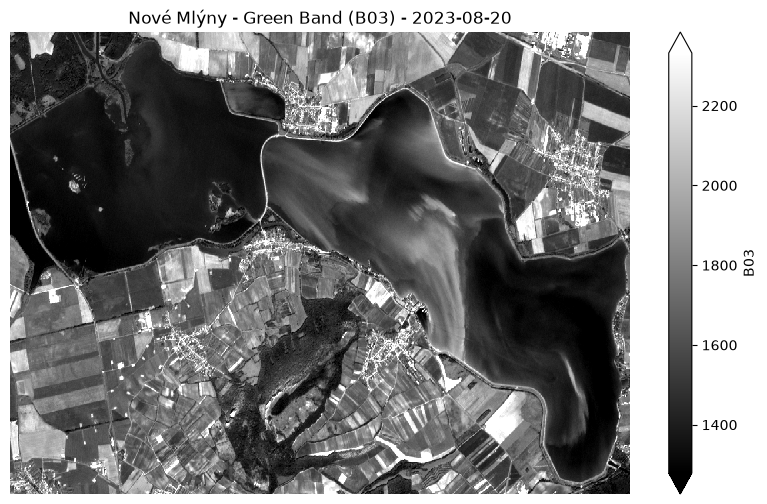

In [12]:
import odc.stac
import matplotlib.pyplot as plt

print(f"Loading bands B03, B11, and SCL for scene: {item.datetime.date()}...")

# Load the data into an xarray Dataset
ds = odc.stac.load(
    [item],
    bands=["B03", "B11", "SCL"],
    bbox=nm_bbox,
    resolution=10  # Force everything to 10m pixel size
).isel(time=0) # We only passed one scene, so grab index 0 to remove the time dimension

print("\nData loaded successfully!")

# Let's take a quick look at the Green band (B03) to ensure we have the lake
plt.figure(figsize=(10, 6))
ds.B03.plot.imshow(robust=True, cmap="gray")
plt.title(f"Nové Mlýny - Green Band (B03) - {item.datetime.date()}")
plt.axis("off")
plt.show()


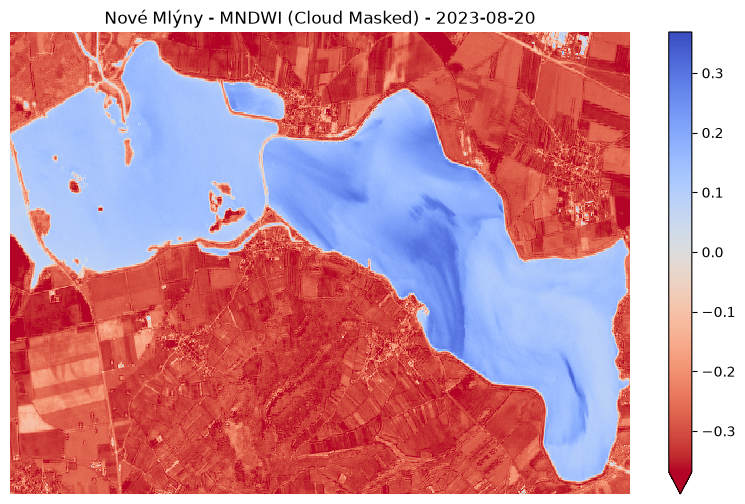

In [13]:
import numpy as np

# Convert the bands to float for math (prevents integer division errors)
b03 = ds.B03.astype(float)
b11 = ds.B11.astype(float)
scl = ds.SCL

# 1. Create Cloud Mask
# ~ means "NOT". So we are keeping pixels that are NOT 3, 8, 9, or 10.
valid_mask = ~scl.isin([3, 8, 9, 10])

# 2. Calculate MNDWI: (Green - SWIR) / (Green + SWIR)
# We add a tiny number (1e-8) to the denominator to prevent division by zero errors on edge pixels
mndwi = (b03 - b11) / (b03 + b11 + 1e-8)

# 3. Apply the cloud mask to the MNDWI 
# .where() keeps the pixel if the mask is True, otherwise sets it to NaN (NoData)
mndwi_masked = mndwi.where(valid_mask)

# Let's plot the MNDWI!
plt.figure(figsize=(10, 6))
# coolwarm_r makes high values (water) Blue, and low values (land) Red.
mndwi_masked.plot.imshow(robust=True, cmap="coolwarm_r") 
plt.title(f"Nové Mlýny - MNDWI (Cloud Masked) - {item.datetime.date()}")
plt.axis("off")
plt.show()



--- Results ---
Date: 2023-08-20
Calculated Water Surface Area: 22.60 km²
Historical Max (from HydroLAKES): 22.75 km²
Current Capacity: 99.4%


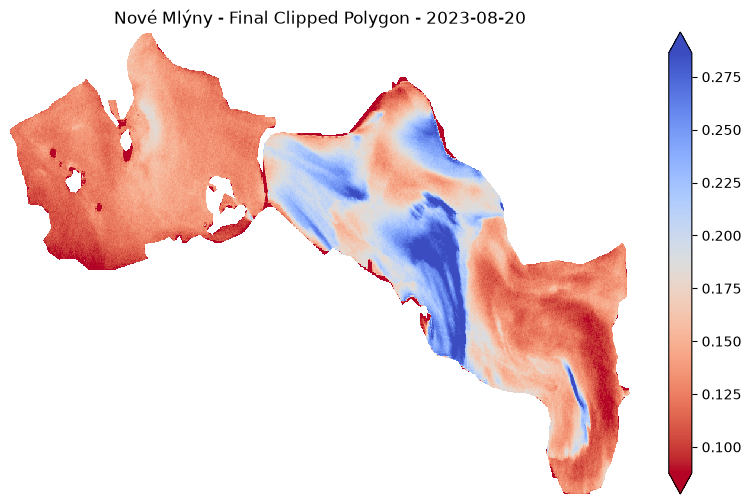

In [16]:
import rioxarray

# 1. Get the TRUE Coordinate Reference System (CRS) of the loaded satellite data
image_crs = ds.rio.crs

# 2. Project our GeoJSON polygon to the image's metric grid
nove_mlyny_projected = nove_mlyny.to_crs(image_crs)

# 3. Make sure the MNDWI array retains the true CRS
mndwi_masked.rio.write_crs(image_crs, inplace=True)

# 4. Clip the MNDWI array first (this safely puts NaN outside the polygon)
mndwi_clipped = mndwi_masked.rio.clip(nove_mlyny_projected.geometry.values, nove_mlyny_projected.crs)

# 5. Apply the threshold to the clipped array
water_clipped = mndwi_clipped > 0.0

# 6. Count and Calculate Area
# Only pixels that are strictly > 0.0 (water inside the polygon) will be True (1)
total_water_pixels = int(water_clipped.sum().values)
pixel_size_m2 = 10 * 10 
area_km2 = (total_water_pixels * pixel_size_m2) / 1_000_000

print(f"\n--- Results ---")
print(f"Date: {item.datetime.date()}")
print(f"Calculated Water Surface Area: {area_km2:.2f} km²")
print(f"Historical Max (from HydroLAKES): {nove_mlyny['Lake_area'].values[0]:.2f} km²")
print(f"Current Capacity: {(area_km2 / nove_mlyny['Lake_area'].values[0]) * 100:.1f}%")

# Plot the clipped float array so we can see the exact cookie-cutter shape
plt.figure(figsize=(10, 6))
mndwi_clipped.plot.imshow(robust=True, cmap="coolwarm_r")
plt.title(f"Nové Mlýny - Final Clipped Polygon - {item.datetime.date()}")
plt.axis("off")
plt.show()



In [19]:
import geopandas as gpd

# --- Configuration ---
GDB_PATH = r"data\hydrolakes\HydroLAKES_polys_v10.gdb"
OUTPUT_PARQUET = r"data\eu_water_surfaces.parquet"
MIN_AREA_KM2 = 0.3
# Adjust this list to match exactly the regions you care about
TARGET_COUNTRIES = [
    "Czech Republic", "Slovakia", "Germany", "Poland", "Austria", 
    "Switzerland", "Hungary", "France", "Netherlands", "Belgium", 
    "Luxembourg", "Spain", "Portugal", "Italy", "Greece", 
    "Romania", "Bulgaria", "Croatia", "Slovenia", "Serbia", 
    "Bosnia and Herzegovina", "Montenegro", "Albania", "Macedonia" 
]

# ---------------------

def build_vector_base():
    print(f"Reading HydroLAKES from {GDB_PATH}...")
    gdf = gpd.read_file(GDB_PATH)
    print(f"Original dataset: {len(gdf)} lakes globally.")
    
    # 1. Filter for Reservoirs (Lake_type = 2)
    filtered = gdf[gdf['Lake_type'] == 2].copy()
    
    # 2. Filter by minimum surface area
    # Note: Depending on the HydroLAKES version, the column is 'Lake_area' or 'Surf_area'
    area_col = 'Lake_area' if 'Lake_area' in filtered.columns else 'Surf_area'
    filtered = filtered[filtered[area_col] >= MIN_AREA_KM2]
    
    # 3. Filter by your target countries
    # HydroLAKES 'Country' column can contain comma-separated strings for border lakes
    country_pattern = '|'.join(TARGET_COUNTRIES)
    filtered = filtered[filtered['Country'].str.contains(country_pattern, case=False, na=False)]
    
    print(f"Filtered down to {len(filtered)} target reservoirs.")
    
    # 4. Save to GeoParquet for modern stack compatibility
    print(f"Saving optimized dataset to {OUTPUT_PARQUET}...")
    filtered.to_parquet(OUTPUT_PARQUET)
    print("Done!")

if __name__ == "__main__":
    build_vector_base()


Reading HydroLAKES from data\hydrolakes\HydroLAKES_polys_v10.gdb...
Original dataset: 1427688 lakes globally.
Filtered down to 867 target reservoirs.
Saving optimized dataset to data\eu_water_surfaces.parquet...
Done!


### water_trends_history parquet analysis

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Set some visualization preferences
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [ ]:
file_path = 'data\water_trends_history.parquet'
df = pd.read_parquet(file_path)
df.head()

,date,name,country,water_area_km2,water_percent,smoothed_area_km2
0,2018-01-28,Albufeira da Canicada,Portugal,0.91,11.33,0.91
1,2018-02-22,Albufeira da Canicada,Portugal,6.00,74.50,3.45
2,2018-03-21,Albufeira da Canicada,Portugal,5.79,71.95,4.23
3,2018-04-18,Albufeira da Canicada,Portugal,4.77,59.25,5.52
4,2018-05-05,Albufeira da Canicada,Portugal,5.76,71.51,5.44


In [7]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 93636 entries, 0 to 93635
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            93636 non-null  datetime64[us]
 1   name            7128 non-null   str           
 2   country         93636 non-null  str           
 3   water_area_km2  93528 non-null  float64       
 4   water_percent   93528 non-null  float64       
dtypes: datetime64[us](1), float64(2), str(2)
memory usage: 4.3 MB


In [8]:

df.describe()


,date,water_area_km2,water_percent
count,93636,93528.000000,93528.000000
mean,2022-07-01 22:45:16.493656,9.471204,75.217571
min,2018-01-01 00:00:00,0.025102,10.005109
25%,2020-03-31 18:00:00,1.647748,64.318773
50%,2022-06-30 12:00:00,3.557223,81.155327
75%,2024-09-30 06:00:00,9.096788,91.501117
max,2026-12-15 00:00:00,244.937974,100.000000
std,NaN,18.519932,20.918000


In [9]:
missing_names_df = df[df['name'].isnull()]

print(f"Total rows missing names: {len(missing_names_df)}")
print("\nCountries with the most missing names:")
print(missing_names_df['country'].value_counts().head(10))

print("\nSample of rows that DO have names:")
display(df[df['name'].notnull()].head())


Total rows missing names: 86508

Countries with the most missing names:
country
Spain             25164
France            10908
Romania            7776
Italy              7668
Germany            5616
Bulgaria           4860
Portugal           4644
Czech Republic     3780
Switzerland        3348
Poland             2808
Name: count, dtype: int64

Sample of rows that DO have names:


,date,name,country,water_area_km2,water_percent
0,2018-01-22,Lake Tisza,Hungary,125.696371,79.602246
1,2018-02-19,Lake Tisza,Hungary,125.696371,79.602246
2,2018-03-01,Lake Tisza,Hungary,127.866849,80.976789
3,2018-04-12,Lake Tisza,Hungary,136.982860,86.749866
4,2018-05-07,Lake Tisza,Hungary,137.054344,86.795137


In [10]:
nans_df = df[df['water_area_km2'].isnull()]

print(f"Total rows with NaN area: {len(nans_df)}")
print("\nNaNs by Country:")
print(nans_df['country'].value_counts().head())

print("\nSample of NaN rows:")
display(nans_df.head())


Total rows with NaN area: 108

NaNs by Country:
country
Spain    108
Name: count, dtype: int64

Sample of NaN rows:


,date,name,country,water_area_km2,water_percent
10908,2018-01-15,NaN,Spain,NaN,NaN
10909,2018-02-21,NaN,Spain,NaN,NaN
10910,2018-03-21,NaN,Spain,NaN,NaN
10911,2018-04-25,NaN,Spain,NaN,NaN
10912,2018-05-15,NaN,Spain,NaN,NaN


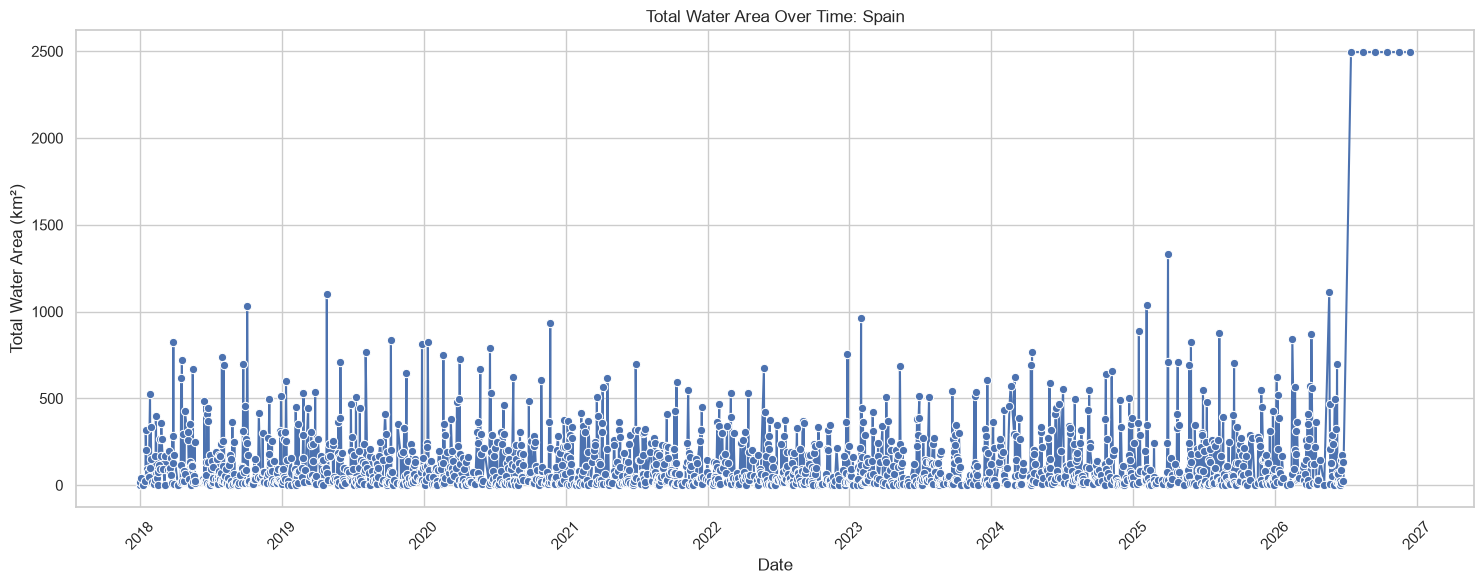

In [11]:
target_country = 'Spain' 

country_data = df[df['country'] == target_country].groupby('date')['water_area_km2'].sum().reset_index()

plt.figure(figsize=(15, 6))
sns.lineplot(data=country_data, x='date', y='water_area_km2', marker='o', linestyle='-')
plt.title(f'Total Water Area Over Time: {target_country}')
plt.ylabel('Total Water Area (km²)')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
import datetime
today = pd.to_datetime('today')
df_clean = df[df['date'] <= today].copy()

df_clean = df_clean.dropna(subset=['water_area_km2'])

print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")


Original rows: 93636
Cleaned rows: 88332
Rows removed: 5304


Plotting data for: Valdecanas


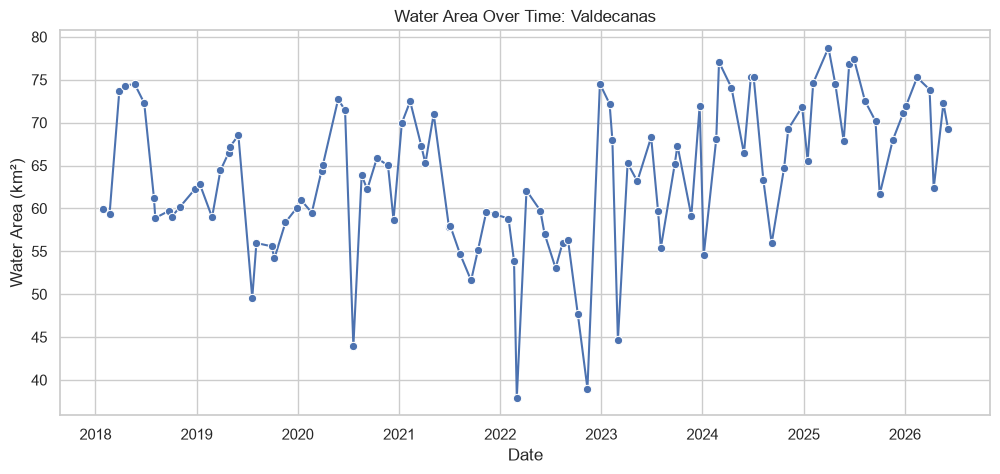

In [13]:

spain_lakes = df_clean[(df_clean['country'] == 'Spain') & (df_clean['name'].notnull())]
largest_spain_lake = spain_lakes.groupby('name')['water_area_km2'].mean().idxmax()

print(f"Plotting data for: {largest_spain_lake}")

single_lake_data = df_clean[df_clean['name'] == largest_spain_lake].sort_values('date')

plt.figure(figsize=(12, 5))
sns.lineplot(data=single_lake_data, x='date', y='water_area_km2', marker='o')
plt.title(f'Water Area Over Time: {largest_spain_lake}')
plt.ylabel('Water Area (km²)')
plt.xlabel('Date')
plt.show()


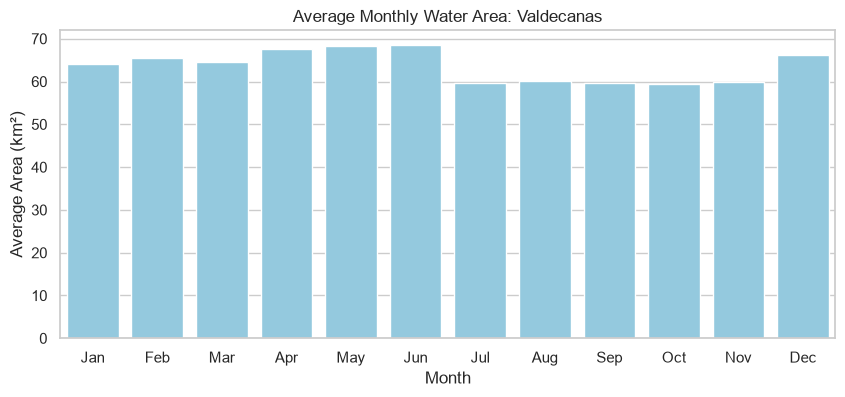

In [14]:

single_lake_data['month'] = single_lake_data['date'].dt.month

monthly_avg = single_lake_data.groupby('month')['water_area_km2'].mean().reset_index()

plt.figure(figsize=(10, 4))
sns.barplot(data=monthly_avg, x='month', y='water_area_km2', color='skyblue')
plt.title(f'Average Monthly Water Area: {largest_spain_lake}')
plt.ylabel('Average Area (km²)')
plt.xlabel('Month')
plt.xticks(range(0,12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()


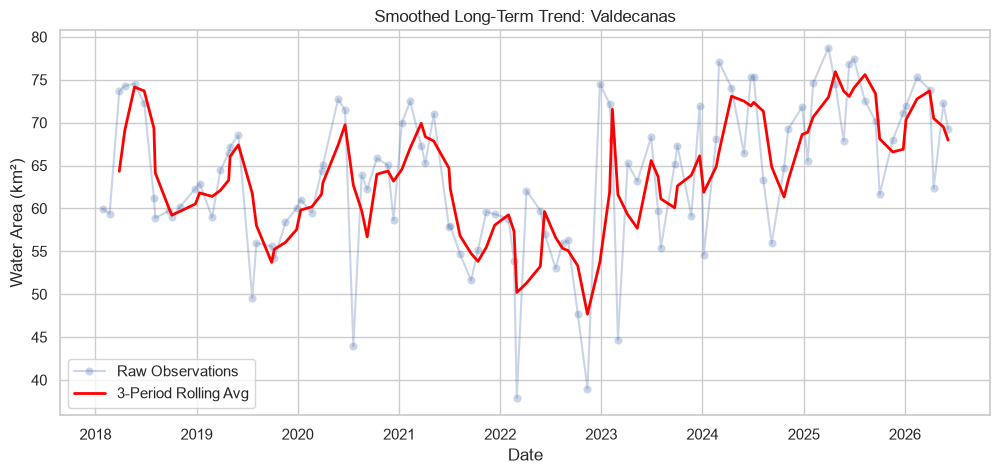

In [15]:

single_lake_data['rolling_area'] = single_lake_data['water_area_km2'].rolling(window=3).mean()

plt.figure(figsize=(12, 5))
sns.lineplot(data=single_lake_data, x='date', y='water_area_km2', marker='o', alpha=0.3, label='Raw Observations')
sns.lineplot(data=single_lake_data, x='date', y='rolling_area', linewidth=2, color='red', label='3-Period Rolling Avg')

plt.title(f'Smoothed Long-Term Trend: {largest_spain_lake}')
plt.ylabel('Water Area (km²)')
plt.xlabel('Date')
plt.legend()
plt.show()


In [ ]:
# Save the cleaned dataset to a new parquet file, ready for production!
cleaned_file_path = 'water_trends_history_clean.parquet'

# We don't need the 'month' or 'rolling_area' columns we just created for the whole dataset, 
# so we just export df_clean
df_clean.to_parquet(cleaned_file_path, index=False)

print(f"Cleaned dataset saved successfully to: {cleaned_file_path}")



In [19]:
# 1. Read the raw checkpoint data that we know has the IDs
df_raw = pd.read_csv('data/checkpoint.csv')

# 2. Calculate the water_percent (area / max_area)
max_areas = df_raw.groupby('hylak_id')['water_area_km2'].max().reset_index()
max_areas = max_areas.rename(columns={'water_area_km2': 'max_area'})

df_raw = df_raw.merge(max_areas, on='hylak_id')
df_raw['water_percent'] = (df_raw['water_area_km2'] / df_raw['max_area']) * 100
df_raw = df_raw.drop(columns=['max_area'])

# Convert date to datetime just to be safe
df_raw['date'] = pd.to_datetime(df_raw['date'])

# 3. Save the fixed dataset back to parquet
df_raw.to_parquet('data/water_trends_history.parquet', index=False)
print("Fixed raw dataset saved successfully!")
print("Columns are now:", df_raw.columns.tolist())


Fixed raw dataset saved successfully!
Columns are now: ['hylak_id', 'name', 'country', 'date', 'water_area_km2', 'water_percent']


Testing unnamed lake with Hylak ID: 1293


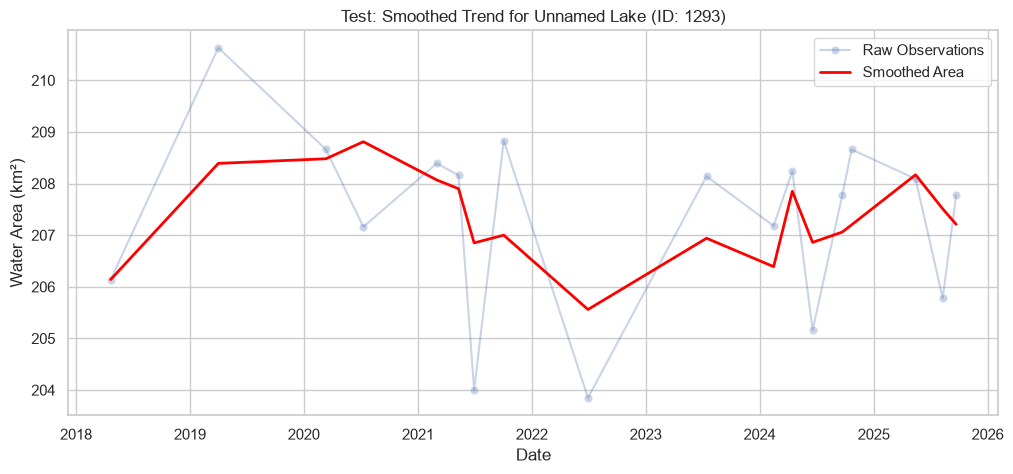

In [20]:
# Load the newly created web-ready data
web_df = pd.read_parquet('data/water_trends_history_web.parquet')

# 1. Let's find a lake that specifically DOES NOT have a name to test our fix!
unnamed_lakes = web_df[web_df['name'].isnull()]['hylak_id'].unique()

# Grab the first unnamed lake ID we find
test_lake_id = unnamed_lakes[0]
print(f"Testing unnamed lake with Hylak ID: {test_lake_id}")

# 2. Filter the data for just this one specific lake
test_data = web_df[web_df['hylak_id'] == test_lake_id].sort_values('date')

# 3. Plot the raw vs smoothed data
plt.figure(figsize=(12, 5))
# Plot original data slightly faded
sns.lineplot(data=test_data, x='date', y='water_area_km2', marker='o', alpha=0.3, label='Raw Observations')
# Plot our new smoothed data strongly
sns.lineplot(data=test_data, x='date', y='smoothed_area_km2', linewidth=2, color='red', label='Smoothed Area')

plt.title(f'Test: Smoothed Trend for Unnamed Lake (ID: {test_lake_id})')
plt.ylabel('Water Area (km²)')
plt.xlabel('Date')
plt.legend()
plt.show()
